# Perbandingan Support Vector Machine dan Random Forest, pada Klasifikasi Kelainan Jantung Sinyal Phonocardiogram Menggunakan Fitur DWT, MFCC, dan Entropy-Based

Nama Anggota:
1. Aisyah Imani Khoirunnisa (24031554020)
2. Aryanti Indah Lestari (24031554196)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import pywt
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
TRAIN_PATH = "/content/drive/Shareddrives/PROJECT_PM/training"

In [ ]:
train_folders = [
    "training-a",
    "training-b",
    "training-c",
    "training-d",
    "training-e",
    "training-f"
]

In [ ]:
train_data = []
for folder in train_folders:
    folder_path = os.path.join(TRAIN_PATH, folder)
    ref_file = os.path.join(folder_path, "REFERENCE.csv")
    reference = pd.read_csv(
        ref_file,
        header=None,
        names=["filename", "label"]
    )

    for idx, row in reference.iterrows():
        file_name = row["filename"] + ".wav"
        file_path = os.path.join(folder_path, file_name)
        label = row["label"]
        if label == -1:
            label = 1  # abnormal = 1
        else:
            label = 0 # normal = 0
        train_data.append([file_path, label])

train_df = pd.DataFrame(
    train_data,
    columns=["path", "label"]
)

print(train_df.head())
print("Jumlah Training:", len(train_df))

                                                path  label
0  /content/drive/Shareddrives/PROJECT_PM/trainin...      0
1  /content/drive/Shareddrives/PROJECT_PM/trainin...      0
2  /content/drive/Shareddrives/PROJECT_PM/trainin...      0
3  /content/drive/Shareddrives/PROJECT_PM/trainin...      0
4  /content/drive/Shareddrives/PROJECT_PM/trainin...      0
Jumlah Training: 3240


# Preprocessing



### split data



In [ ]:
train_df_split, test_df_split = train_test_split(
    train_df,
    test_size=0.3,
    random_state=42,
    stratify=train_df['label']
)

print("Train :", len(train_df_split))
print("Test  :", len(test_df_split))

print("\nDistribusi Train")
print(train_df_split['label'].value_counts())

print("\nDistribusi Test")
print(test_df_split['label'].value_counts())

Train : 2268
Test  : 972

Distribusi Train
label
1    1803
0     465
Name: count, dtype: int64

Distribusi Test
label
1    772
0    200
Name: count, dtype: int64


### Training

Resampling dan Padding

In [ ]:
TARGET_SR = 2000
TARGET_LENGTH = 10000

In [ ]:
train_signals = []
for path in train_df_split['path']:
    signal, sr = librosa.load(
        path,
        sr=TARGET_SR
    )
    train_signals.append(signal)
print(len(train_signals))

2268


Normalisasi

In [ ]:
train_signals_norm = []
for signal in train_signals:
    signal = signal / np.max(np.abs(signal))
    train_signals_norm.append(signal)
print(len(train_signals_norm))

2268


Denoising

In [ ]:
train_signals_denoised = []
for signal in train_signals_norm:
    signal[np.abs(signal) < 0.01] = 0
    train_signals_denoised.append(signal)
print(len(train_signals_denoised))

2268


In [ ]:
train_signals_final = []
for signal in train_signals_denoised:
    if len(signal) < TARGET_LENGTH:
        pad_width = TARGET_LENGTH - len(signal)
        signal = np.pad(signal, (0, pad_width))
    else:
        signal = signal[:TARGET_LENGTH]
    train_signals_final.append(signal)
print(len(train_signals_final))

2268


### Testing

In [ ]:
test_signals = []

for path in test_df_split['path']:

    signal, sr = librosa.load(
        path,
        sr=TARGET_SR
    )

    test_signals.append(signal)

print(len(test_signals))

972


Normalisasi

In [ ]:
test_signals_norm = []
for signal in test_signals:
    signal = signal / np.max(np.abs(signal))
    test_signals_norm.append(signal)
print(len(test_signals_norm))

972


Denoising

In [ ]:
test_signals_denoised = []
for signal in test_signals_norm:
    signal[np.abs(signal) < 0.01] = 0
    test_signals_denoised.append(signal)
print(len(test_signals_denoised))

972


In [ ]:
test_signals_final = []
for signal in test_signals_denoised:
    if len(signal) < TARGET_LENGTH:
        pad_width = TARGET_LENGTH - len(signal)
        signal = np.pad(
            signal,
            (0, pad_width)
        )
    else:
        signal = signal[:TARGET_LENGTH]
    test_signals_final.append(signal)
print(len(test_signals_final))

972


# Analisis Data Eksploratif

Distribusi label train


Distribusi Label Training:
label
Abnormal    1803
Normal       465
Name: count, dtype: int64


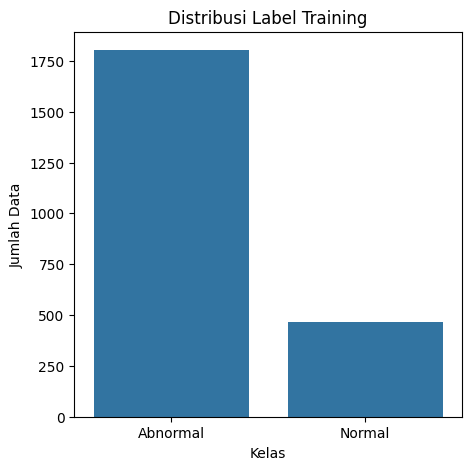

In [ ]:
label_names = train_df_split['label'].replace({
    0: 'Normal',
    1: 'Abnormal'
})

print("\nDistribusi Label Training:")
print(label_names.value_counts())

plt.figure(figsize=(5,5))

sns.countplot(
    x=label_names
)

plt.title('Distribusi Label Training')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')

plt.show()

Wavefrom

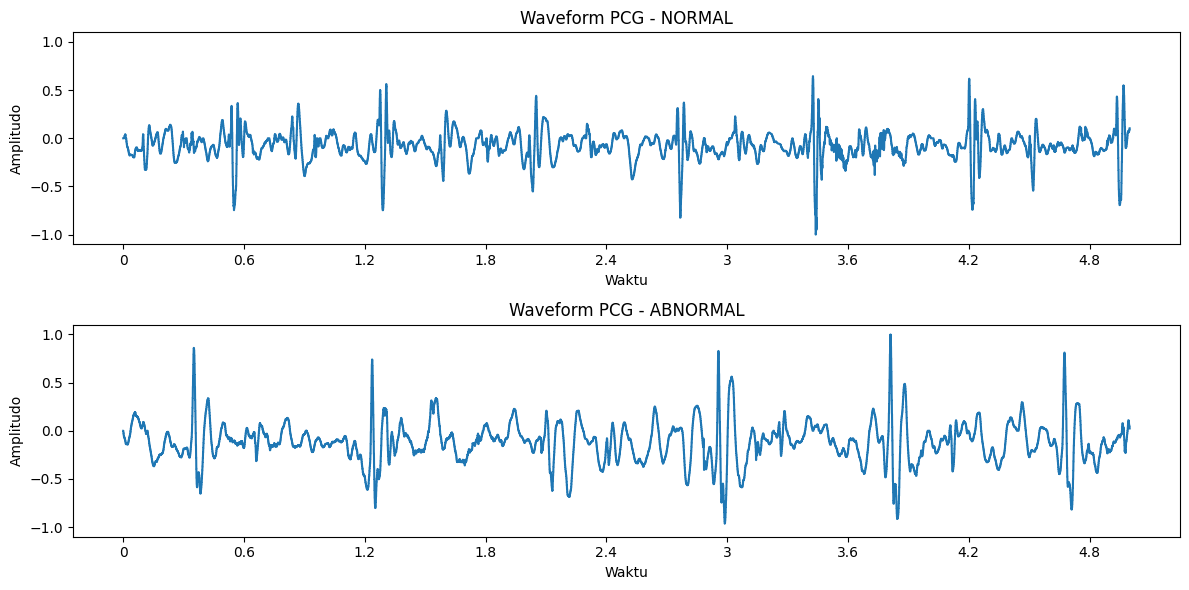

In [ ]:
normal_idx = np.where(train_df['label'] == 0)[0][0]
abnormal_idx = np.where(train_df['label'] == 1)[0][0]

normal_signal = train_signals_final[normal_idx]
abnormal_signal = train_signals_final[abnormal_idx]

fig, axes = plt.subplots(2, 1, figsize=(12,6))

librosa.display.waveshow(
    normal_signal,
    sr=TARGET_SR,
    ax=axes[0]
)

axes[0].set_title("Waveform PCG - NORMAL")
axes[0].set_xlabel("Waktu")
axes[0].set_ylabel("Amplitudo")

librosa.display.waveshow(
    abnormal_signal,
    sr=TARGET_SR,
    ax=axes[1]
)

axes[1].set_title("Waveform PCG - ABNORMAL")
axes[1].set_xlabel("Waktu")
axes[1].set_ylabel("Amplitudo")

plt.tight_layout()
plt.show()

Spectogram

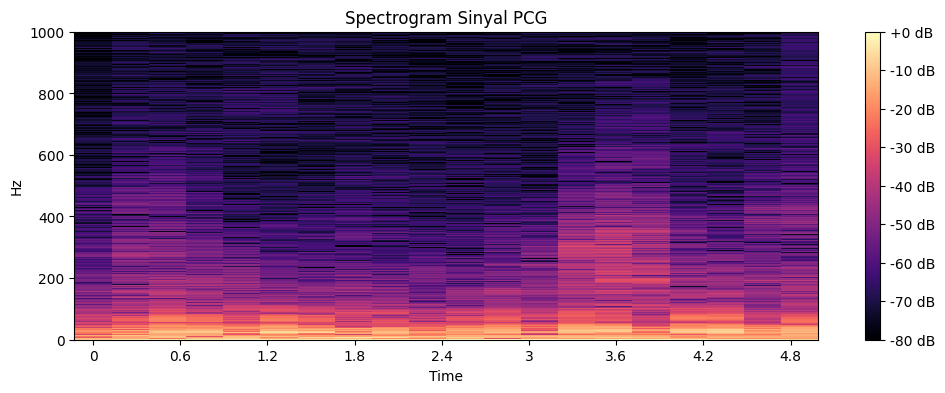

In [ ]:
signal = train_signals_final[0]
stft = librosa.stft(signal)

spectrogram = librosa.amplitude_to_db(
    np.abs(stft),
    ref=np.max
)

plt.figure(figsize=(12,4))

librosa.display.specshow(
    spectrogram,
    sr=TARGET_SR,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram Sinyal PCG')
plt.show()

# Augmentasi

In [ ]:
np.random.seed(42)

def augment_signal(signal):

    signal_aug = signal.copy()

    # amplitude scaling
    scale = np.random.uniform(0.95, 1.05)
    signal_aug = signal_aug * scale

    # gaussian noise ringan
    noise = np.random.normal(
        0,
        0.001,
        len(signal_aug)
    )

    signal_aug = signal_aug + noise

    # time shifting kecil
    shift = np.random.randint(-50, 50)

    signal_aug = np.roll(
        signal_aug,
        shift
    )

    return signal_aug

In [ ]:
# data asli
train_signals_balanced = train_signals_final.copy()
train_labels_balanced = train_df_split['label'].tolist()

# hitung distribusi kelas
normal_idx = np.where(train_df_split['label'] == 0)[0]
abnormal_idx = np.where(train_df_split['label'] == 1)[0]

normal_count = len(normal_idx)
abnormal_count = len(abnormal_idx)

print("Normal :", normal_count)
print("Abnormal :", abnormal_count)

Normal : 465
Abnormal : 1803


In [ ]:
# cari kelas minoritas
if normal_count < abnormal_count:

    minority_idx = normal_idx
    majority_count = abnormal_count
    minority_label = 0

else:

    minority_idx = abnormal_idx
    majority_count = normal_count
    minority_label = 1

needed = majority_count - len(minority_idx)

print("Jumlah data augmentasi:", needed)

Jumlah data augmentasi: 1338


In [ ]:
# augmentasi sampai seimbang
for i in range(needed):

    idx = np.random.choice(minority_idx)

    original_signal = train_signals_final[idx]

    augmented_signal = augment_signal(
        original_signal
    )

    train_signals_balanced.append(
        augmented_signal
    )

    train_labels_balanced.append(
        minority_label
    )

print("Jumlah data setelah augmentasi:",
      len(train_signals_balanced))

print(pd.Series(
    train_labels_balanced
).value_counts())

Jumlah data setelah augmentasi: 3606
1    1803
0    1803
Name: count, dtype: int64


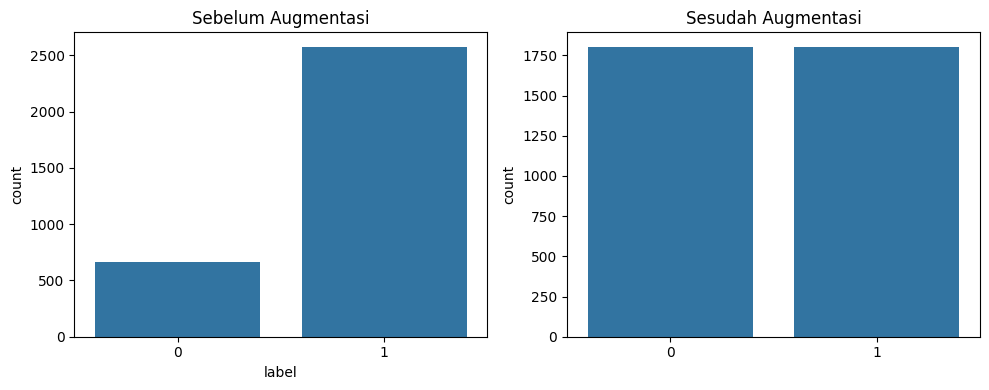

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=train_df['label'])
plt.title("Sebelum Augmentasi")

plt.subplot(1,2,2)
sns.countplot(x=train_labels_balanced)
plt.title("Sesudah Augmentasi")

plt.tight_layout()
plt.show()

# Ekstraksi Fitur DWT, MFCC, Entropy Based

Fungsi Entropy

In [ ]:
from scipy.stats import entropy

def shannon_entropy(signal):

    hist, _ = np.histogram(
        signal,
        bins=100,
        density=True
    )

    hist = hist + 1e-10

    return entropy(hist)

## Data training

DWT

In [ ]:
X_train_dwt = []

for signal in train_signals_balanced:

    coeffs = pywt.wavedec(
        signal,
        wavelet='db4',
        level=4
    )

    dwt_features = []

    for coeff in coeffs:

        dwt_features.extend([
            np.mean(coeff),
            np.std(coeff),
            np.min(coeff),
            np.max(coeff),
            np.median(coeff),
            np.percentile(coeff, 25),
            np.percentile(coeff, 75),
            np.sqrt(np.mean(coeff**2))
        ])

    X_train_dwt.append(dwt_features)

X_train_dwt = np.array(X_train_dwt)

print(X_train_dwt.shape)

(3606, 40)


MFCC

In [ ]:
X_train_mfcc = []

for signal in train_signals_balanced:

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=TARGET_SR,
        n_mfcc=13
    )

    mfcc_features = []

    mfcc_features.extend(
        np.mean(mfcc, axis=1)
    )

    mfcc_features.extend(
        np.std(mfcc, axis=1)
    )

    X_train_mfcc.append(mfcc_features)

X_train_mfcc = np.array(X_train_mfcc)

print(X_train_mfcc.shape)

(3606, 26)


Entropy Based

In [ ]:
X_train_entropy = []

for signal in train_signals_balanced:

    entropy_feature = shannon_entropy(signal)

    X_train_entropy.append(
        [entropy_feature]
    )

X_train_entropy = np.array(
    X_train_entropy
)

print(X_train_entropy.shape)

(3606, 1)


In [ ]:
X_train = np.concatenate(
    [
        X_train_dwt,
        X_train_mfcc,
        X_train_entropy
    ],
    axis=1
)

y_train = np.array(
    train_labels_balanced
)

print(X_train.shape)
print(y_train.shape)

(3606, 67)
(3606,)


In [ ]:
print("Jumlah fitur:", X_train.shape[1])

Jumlah fitur: 67


## Data Testing

DWT

In [ ]:
X_test_dwt = []

for signal in test_signals_final:

    coeffs = pywt.wavedec(
        signal,
        wavelet='db4',
        level=4
    )

    dwt_features = []

    for coeff in coeffs:

        dwt_features.extend([
            np.mean(coeff),
            np.std(coeff),
            np.min(coeff),
            np.max(coeff),
            np.median(coeff),
            np.percentile(coeff, 25),
            np.percentile(coeff, 75),
            np.sqrt(np.mean(coeff**2))
        ])

    X_test_dwt.append(dwt_features)

X_test_dwt = np.array(X_test_dwt)

print(X_test_dwt.shape)

(972, 40)


MFCC

In [ ]:
X_test_mfcc = []

for signal in test_signals_final:

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=TARGET_SR,
        n_mfcc=13
    )

    mfcc_features = []

    mfcc_features.extend(
        np.mean(mfcc, axis=1)
    )

    mfcc_features.extend(
        np.std(mfcc, axis=1)
    )

    X_test_mfcc.append(mfcc_features)

X_test_mfcc = np.array(X_test_mfcc)

print(X_test_mfcc.shape)

(972, 26)


Entropy Based

In [ ]:
X_test_entropy = []

for signal in test_signals_final:

    entropy_feature = shannon_entropy(signal)

    X_test_entropy.append(
        [entropy_feature]
    )

X_test_entropy = np.array(
    X_test_entropy
)

print(X_test_entropy.shape)

(972, 1)


In [ ]:
X_test = np.concatenate(
    [
        X_test_dwt,
        X_test_mfcc,
        X_test_entropy
    ],
    axis=1
)

y_test = np.array(
    test_df_split['label']
)

print(X_test.shape)
print(y_test.shape)

(972, 67)
(972,)


# Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai")

Scaling selesai


# SVM

In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(C=10, class_weight='balanced', random_state=42)

In [ ]:
y_pred = svm_model.predict(X_test_scaled)

# Evaluasi SVM

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8981481481481481


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Abnormal"]
))

              precision    recall  f1-score   support

      Normal       0.74      0.79      0.76       200
    Abnormal       0.94      0.93      0.94       772

    accuracy                           0.90       972
   macro avg       0.84      0.86      0.85       972
weighted avg       0.90      0.90      0.90       972



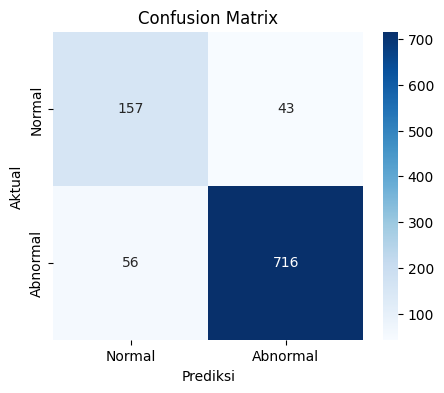

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")

plt.show()

# Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

# Evaluasi Random Forest

In [ ]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Accuracy RF :", accuracy_rf)

Accuracy RF : 0.8899176954732511


In [ ]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Normal", "Abnormal"]
))

              precision    recall  f1-score   support

      Normal       0.70      0.81      0.75       200
    Abnormal       0.95      0.91      0.93       772

    accuracy                           0.89       972
   macro avg       0.83      0.86      0.84       972
weighted avg       0.90      0.89      0.89       972



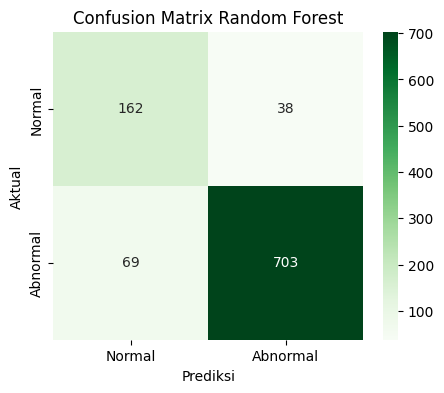

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Random Forest")

plt.show()